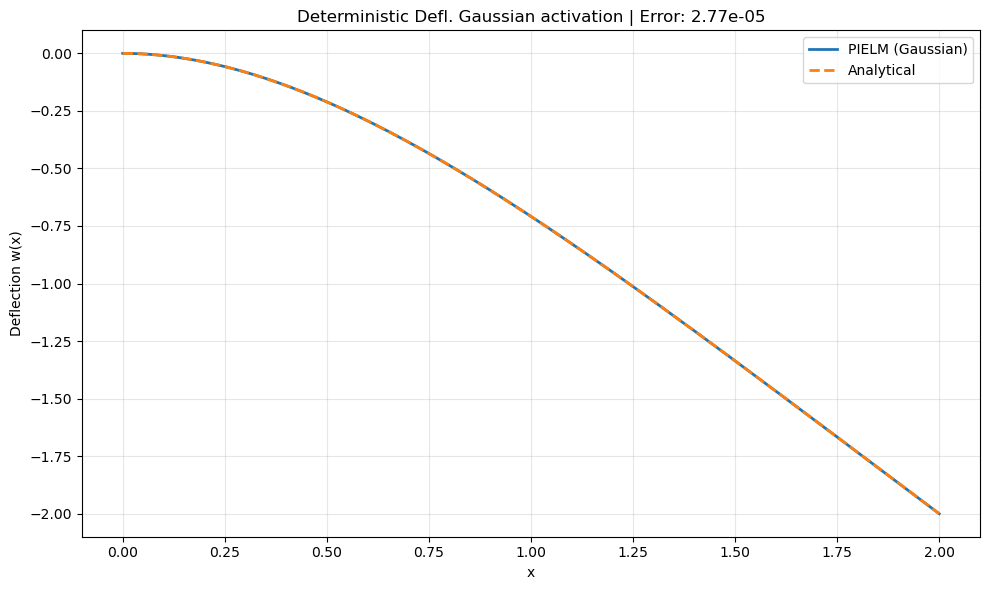

Training time: 0.1118 s
Relative error: 2.77e-05
β₀ = -3.988854


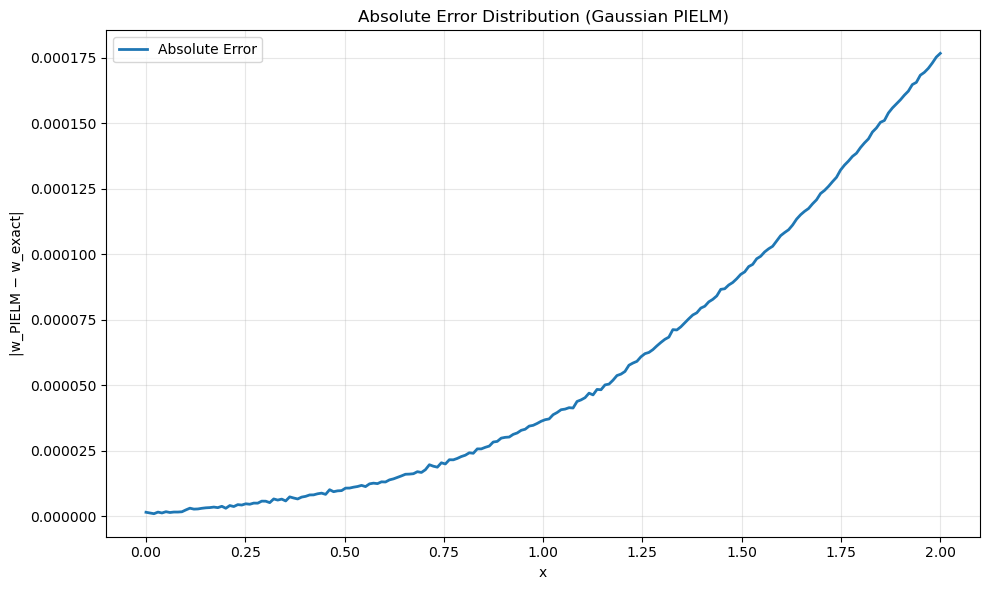

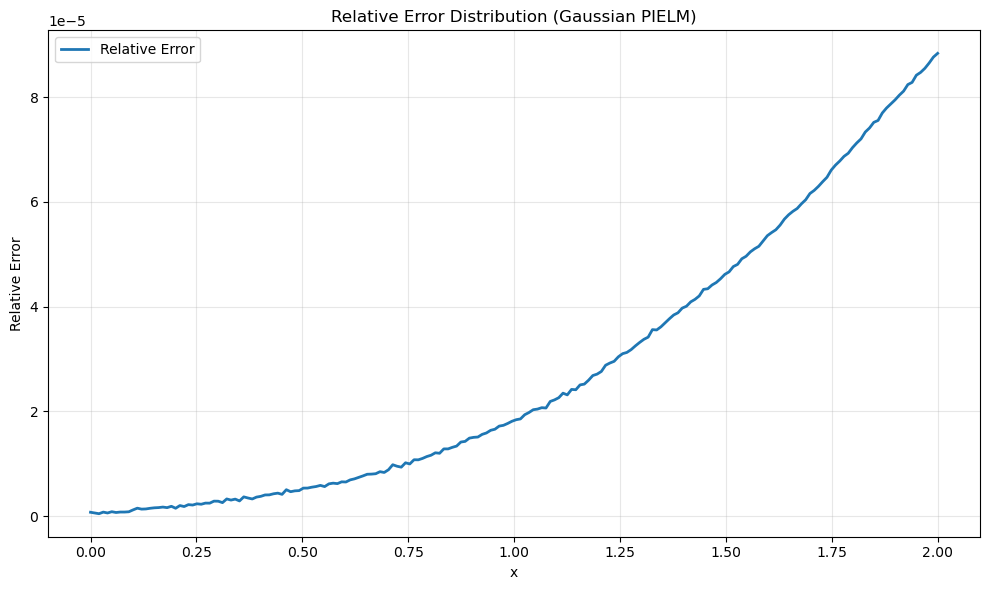

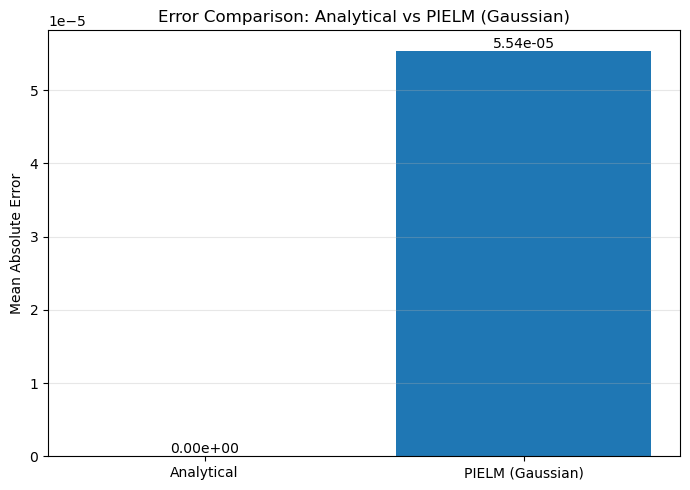

In [3]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# PIELM SETUP WITH GAUSSIAN ACTIVATION
# =============================================================================
torch.manual_seed(42)

hidden_size = 40
W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_gaussian(x):
    """Gaussian activation: exp(-(Wx + b)^2)"""
    H_gaussian = torch.exp(-(x @ W + b)**2)
    ones = torch.ones(x.shape[0], 1)
    return torch.cat([ones, H_gaussian], dim=1)

# =============================================================================
# COLLOCATION & BOUNDARY POINTS
# =============================================================================
n_collocation = 100
x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD PDE MATRIX A
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_gaussian(x_c)
A_cols = []

# β₀ term
zero_col = torch.zeros(n_collocation, 1)
A_cols.append(zero_col)

# β₁ to β₄₀ terms
for j in range(1, hidden_size + 1):
    wj = H_c[:, j:j+1]
    w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
    w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
    w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
    w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
    A_cols.append(w_xxxx)

A = E * I * torch.hstack(A_cols)
b_pde = Q * torch.ones(n_collocation, 1)

# =============================================================================
# BUILD BOUNDARY CONSTRAINT MATRIX C
# =============================================================================
def bc_row(x, order):
    H = hidden_layer_gaussian(x)
    row = []
    
    if order == 0:
        row.append(torch.ones(1, 1))
    else:
        row.append(torch.zeros(1, 1))
    
    for j in range(1, hidden_size + 1):
        w = H[:, j:j+1]
        for _ in range(order):
            w = autograd.grad(w.sum(), x, create_graph=True)[0]
        row.append(w)
    
    return torch.hstack(row)

C = torch.vstack([
    bc_row(x_0, 0),   # w(0) = 0
    bc_row(x_0, 1),   # w'(0) = 0
    bc_row(x_L, 2),   # w''(L) = 0
    bc_row(x_L, 3)    # w'''(L) = 0
])

d = torch.zeros(4, 1)

# =============================================================================
# KKT SYSTEM
# =============================================================================
total_beta = hidden_size + 1
total_unknowns = total_beta + 4

KKT = torch.zeros(total_unknowns, total_unknowns)
KKT[:total_beta, :total_beta] = A.T @ A
KKT[:total_beta, total_beta:] = C.T
KKT[total_beta:, :total_beta] = C

rhs = torch.vstack([A.T @ b_pde, d])

alpha = 1e-8 * torch.trace(A.T @ A) / total_beta
KKT += alpha * torch.eye(total_unknowns)

solution = torch.linalg.solve(KKT, rhs)
beta_with_b0 = solution[:total_beta]


# =============================================================================
# PREDICTION AND PLOT
# =============================================================================
x_pred = torch.linspace(0, L, 200).view(-1, 1)
H_pred = hidden_layer_gaussian(x_pred)
w_pred = H_pred @ beta_with_b0
w_exact = analytical_solution(x_pred)
rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.max(torch.abs(w_exact))

plt.figure(figsize=(10, 6))
plt.plot(x_pred, w_pred.detach(), label="PIELM (Gaussian)", linewidth=2)
plt.plot(x_pred, w_exact, "--", label="Analytical", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title(f"Deterministic Defl. Gaussian activation | Error: {rel_error.item():.2e}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training time: {default_timer() - t0:.4f} s")
print(f"Relative error: {rel_error.item():.2e}")
print(f"β₀ = {beta_with_b0[0].item():.6f}")
# =============================================================================
# ERROR ANALYSIS
# =============================================================================
abs_error = torch.abs(w_pred - w_exact)
rel_error_pointwise = abs_error / (torch.max(torch.abs(w_exact)) + 1e-12)
plt.figure(figsize=(10, 6))
plt.plot(x_pred, abs_error.detach(), label="Absolute Error", linewidth=2)
plt.xlabel("x")
plt.ylabel("|w_PIELM − w_exact|")
plt.title("Absolute Error Distribution (Gaussian PIELM)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(x_pred, rel_error_pointwise.detach(), label="Relative Error", linewidth=2)
plt.xlabel("x")
plt.ylabel("Relative Error")
plt.title("Relative Error Distribution (Gaussian PIELM)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# =============================================================================
# ERROR METRICS FOR BAR DIAGRAM
# =============================================================================
abs_error = torch.abs(w_pred - w_exact)

mean_abs_error = torch.mean(abs_error).item()
l2_error = torch.sqrt(torch.mean((w_pred - w_exact) ** 2)).item()
max_error = torch.max(abs_error).item()
# =============================================================================
# BAR DIAGRAM: ERROR COMPARISON
# =============================================================================
labels = ["Analytical", "PIELM (Gaussian)"]
mean_errors = [0.0, mean_abs_error]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, mean_errors)

plt.ylabel("Mean Absolute Error")
plt.title("Error Comparison: Analytical vs PIELM (Gaussian)")
plt.grid(axis="y", alpha=0.3)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2e}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()




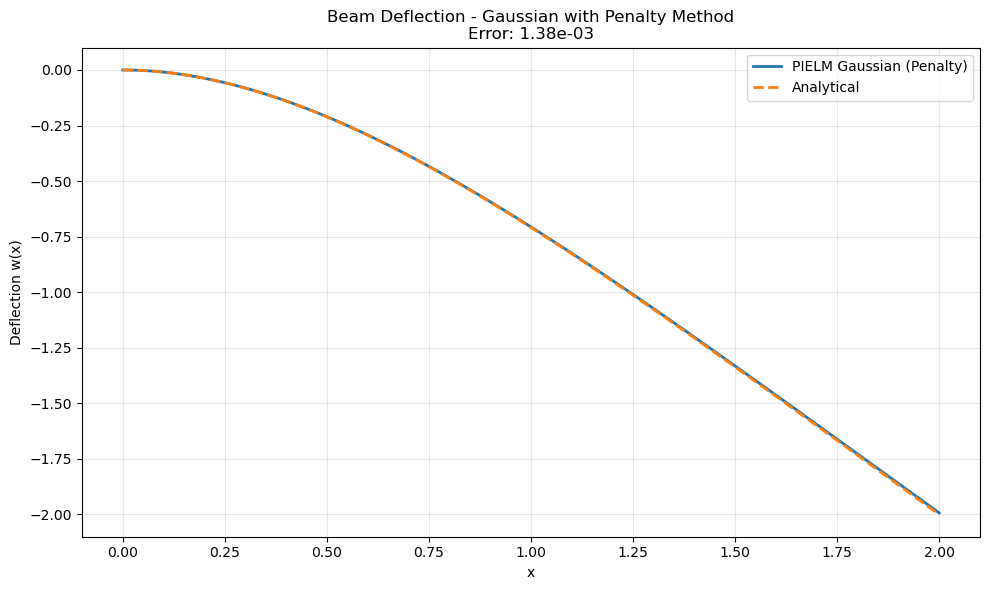

Training time: 0.0989 s

Penalty Method (No KKT) with Gaussian Activation
λ values: w(0)=0: 10000, w'(0)=0: 100, w''(L)=0: 100, w'''(L)=0: 100

Relative error: 1.38e-03
β₀ = -6.594563

Boundary Condition Satisfaction:
  w(0) = 0.000000e+00 (should be 0)
  w'(0) = 4.446507e-04 (should be 0)
  w''(L) = 1.282215e-03 (should be 0)
  w'''(L) = -4.558563e-04 (should be 0)

First 5 β values:
  β₀ = -6.594563
  β1 = -0.019812
  β2 = -0.143047
  β3 = 1.166678
  β4 = -0.031599


In [9]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# PIELM SETUP WITH GAUSSIAN ACTIVATION
# =============================================================================
torch.manual_seed(42)

hidden_size = 40
W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_gaussian(x):
    """Gaussian activation: exp(-(Wx + b)^2)"""
    H_gaussian = torch.exp(-(x @ W + b)**2)
    ones = torch.ones(x.shape[0], 1)
    return torch.cat([ones, H_gaussian], dim=1)

# =============================================================================
# COLLOCATION & BOUNDARY POINTS
# =============================================================================
n_collocation = 100
x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD PDE MATRIX A
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_gaussian(x_c)
A_cols = []

# β₀ term
zero_col = torch.zeros(n_collocation, 1)
A_cols.append(zero_col)

# β₁ to β₄₀ terms
for j in range(1, hidden_size + 1):
    wj = H_c[:, j:j+1]
    w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
    w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
    w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
    w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
    A_cols.append(w_xxxx)

A = E * I * torch.hstack(A_cols)
b_pde = Q * torch.ones(n_collocation, 1)

# =============================================================================
# BUILD BOUNDARY CONSTRAINT MATRICES
# =============================================================================
def bc_row(x, order):
    H = hidden_layer_gaussian(x)
    row = []
    
    if order == 0:
        row.append(torch.ones(1, 1))
    else:
        row.append(torch.zeros(1, 1))
    
    for j in range(1, hidden_size + 1):
        w = H[:, j:j+1]
        for _ in range(order):
            w = autograd.grad(w.sum(), x, create_graph=True)[0]
        row.append(w)
    
    return torch.hstack(row)

# Individual boundary condition matrices
C0 = bc_row(x_0, 0)   # w(0) = 0
C1 = bc_row(x_0, 1)   # w'(0) = 0
C2 = bc_row(x_L, 2)   # w''(L) = 0
C3 = bc_row(x_L, 3)   # w'''(L) = 0

# =============================================================================
# PENALTY METHOD WITHOUT KKT
# =============================================================================
# Your specified λ values
lambda1 = 10000  # for w(0) = 0
lambda2 = 100    # for w'(0) = 0
lambda3 = 100    # for w''(L) = 0
lambda4 = 100    # for w'''(L) = 0

# Build the augmented system using penalty method
M = A.T @ A
M += lambda1 * (C0.T @ C0)
M += lambda2 * (C1.T @ C1)
M += lambda3 * (C2.T @ C2)
M += lambda4 * (C3.T @ C3)

rhs = A.T @ b_pde

# Add small regularization
alpha = 1e-8 * torch.trace(M) / (hidden_size + 1)
M += alpha * torch.eye(hidden_size + 1)

# Solve
beta_with_b0 = torch.linalg.solve(M, rhs)

# =============================================================================
# PREDICTION
# =============================================================================
x_pred = torch.linspace(0, L, 200).view(-1, 1)
H_pred = hidden_layer_gaussian(x_pred)
w_pred = H_pred @ beta_with_b0
w_exact = analytical_solution(x_pred)
rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.max(torch.abs(w_exact))

# =============================================================================
# CHECK BOUNDARY CONDITIONS
# =============================================================================
def compute_derivative_at_point(x_val, order):
    """Helper function to compute derivatives at a point"""
    x_point = torch.tensor([[x_val]], requires_grad=True)
    w_point = hidden_layer_gaussian(x_point) @ beta_with_b0
    
    if order == 0:
        return w_point.item()
    
    dw = autograd.grad(w_point.sum(), x_point, create_graph=True)[0]
    if order == 1:
        return dw.item()
    
    d2w = autograd.grad(dw.sum(), x_point, create_graph=True)[0]
    if order == 2:
        return d2w.item()
    
    d3w = autograd.grad(d2w.sum(), x_point, create_graph=True)[0]
    return d3w.item()

# Compute boundary values
w_0 = compute_derivative_at_point(0.0, 0)
dw_0 = compute_derivative_at_point(0.0, 1)
d2w_L = compute_derivative_at_point(L, 2)
d3w_L = compute_derivative_at_point(L, 3)

# =============================================================================
# SINGLE PLOT (Reunited like your original)
# =============================================================================
plt.figure(figsize=(10, 6))
plt.plot(x_pred.detach().numpy(), w_pred.detach().numpy(), label="PIELM Gaussian (Penalty)", linewidth=2)
plt.plot(x_pred.detach().numpy(), w_exact.detach().numpy(), "--", label="Analytical", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title(f"Beam Deflection - Gaussian with Penalty Method\nError: {rel_error.item():.2e}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# PRINT RESULTS
# =============================================================================
print(f"Training time: {default_timer() - t0:.4f} s")
print(f"\nPenalty Method (No KKT) with Gaussian Activation")
print("="*60)
print(f"λ values: w(0)=0: {lambda1}, w'(0)=0: {lambda2}, w''(L)=0: {lambda3}, w'''(L)=0: {lambda4}")
print(f"\nRelative error: {rel_error.item():.2e}")
print(f"β₀ = {beta_with_b0[0].item():.6f}")

print("\nBoundary Condition Satisfaction:")
print(f"  w(0) = {w_0:.6e} (should be 0)")
print(f"  w'(0) = {dw_0:.6e} (should be 0)")
print(f"  w''(L) = {d2w_L:.6e} (should be 0)")
print(f"  w'''(L) = {d3w_L:.6e} (should be 0)")

print("\nFirst 5 β values:")
for i in range(min(5, len(beta_with_b0))):
    if i == 0:
        print(f"  β₀ = {beta_with_b0[i].item():.6f}")
    else:
        print(f"  β{i} = {beta_with_b0[i].item():.6f}")